<a href="https://colab.research.google.com/github/roboy88/-Mike-Mentzer-vs.-Other-Training-Methods-Olympia-History-Data-Science-Project/blob/main/Mike_Mentzer_vs_Other_Training_Methods_%2B_Olympia_History_Data_Science_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Exercise1.xlsx to Exercise1.xlsx
Saving Exercise2.xlsx to Exercise2.xlsx
Saving Exercise3.xlsx to Exercise3.xlsx
Saving Exercise4.xlsx to Exercise4.xlsx


<ipython-input-2-1a5947ee53fe>:49: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


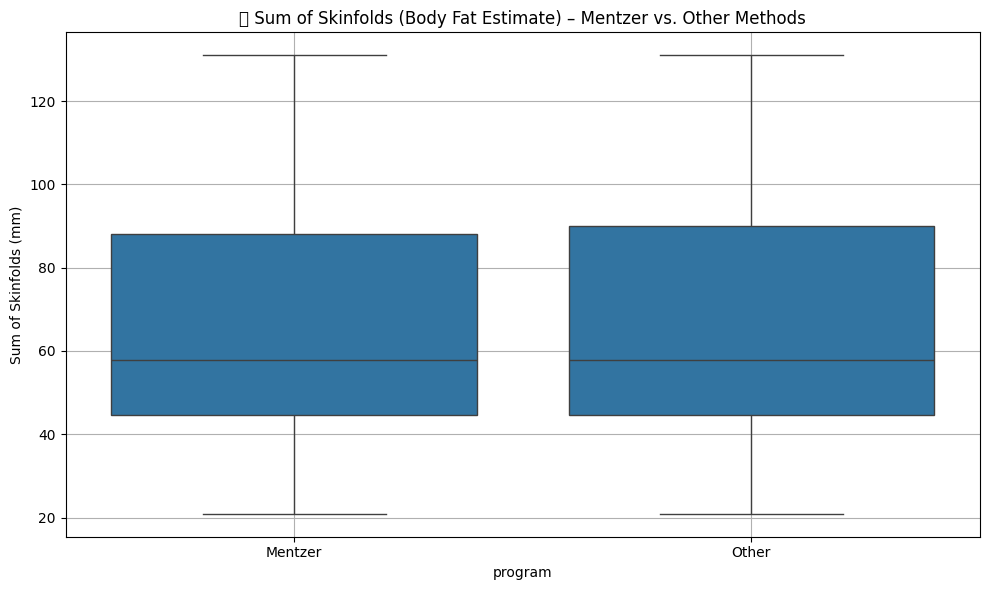

<ipython-input-2-1a5947ee53fe>:57: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


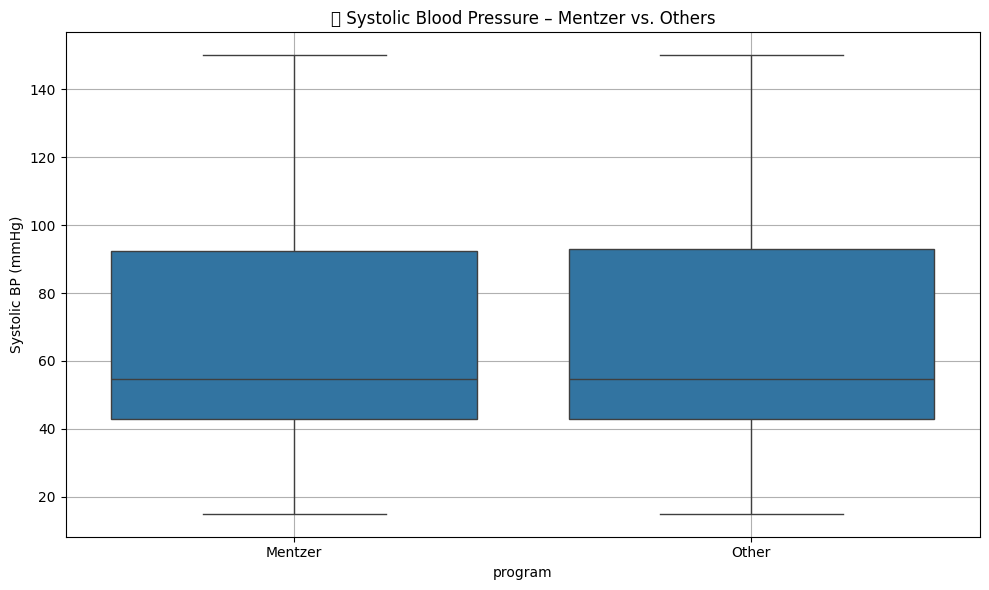

🔢 R² Score: 0.09987543572589053


<ipython-input-2-1a5947ee53fe>:93: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


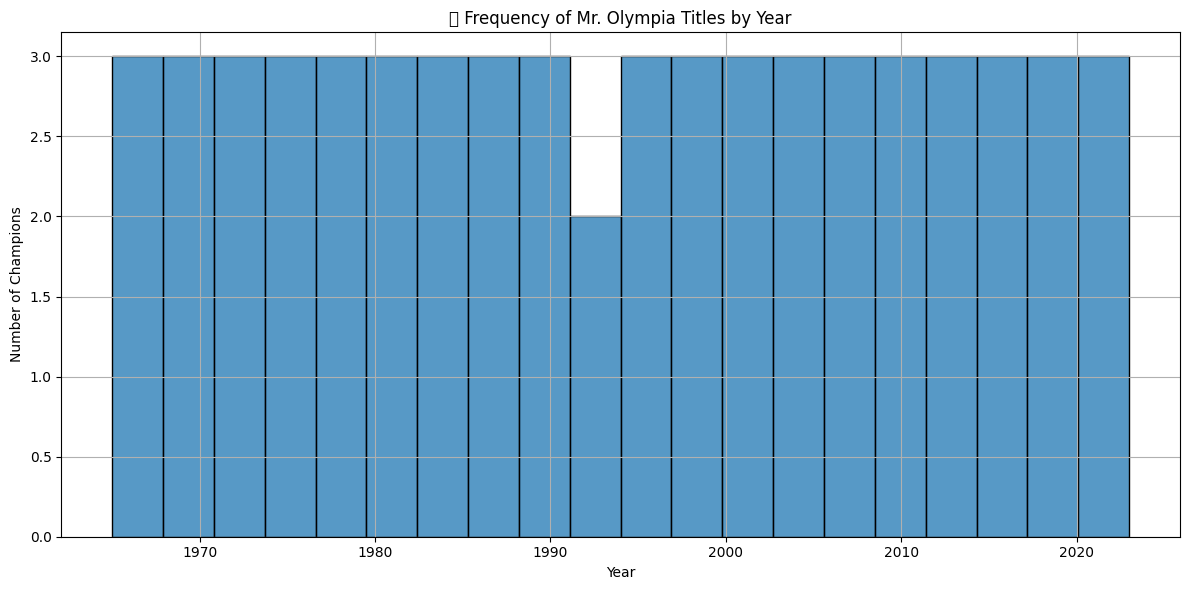

In [2]:


# Step 1: Upload all files manually
from google.colab import files
uploaded = files.upload()
files = list(uploaded.keys())

# Step 2: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import zipfile, os

# Step 3: Unzip Olympia archive if present
zip_files = [f for f in files if f.endswith(".zip")]
if zip_files:
    extract_path = "/content/olympia_data"
    os.makedirs(extract_path, exist_ok=True)
    with zipfile.ZipFile(zip_files[0], 'r') as zip_ref:
        zip_ref.extractall(extract_path)

# Step 4: Load Excel Data (Mentzer vs. Others)
excel_data = []
for file in files:
    if file.endswith(".xlsx"):
        xls = pd.ExcelFile(file)
        for sheet in xls.sheet_names:
            df = xls.parse(sheet, skiprows=2)
            df.columns = [f"col_{i}" for i in range(len(df.columns))]
            df["source"] = f"{file}_{sheet}"
            excel_data.append(df)

df_excel = pd.concat(excel_data, ignore_index=True)
df_excel = df_excel.rename(columns={
    "col_0": "ID",
    "col_1": "SumSkinfolds_mm",
    "col_2": "Systolic_BP"
})
df_excel['program'] = df_excel['source'].apply(lambda x: "Mentzer" if "Exercise1" in x else "Other")

# Step 5: Visualize Mentzer vs. Others
plt.figure(figsize=(10, 6))
sns.boxplot(x="program", y="SumSkinfolds_mm", data=df_excel)
plt.title("📊 Sum of Skinfolds (Body Fat Estimate) – Mentzer vs. Other Methods")
plt.ylabel("Sum of Skinfolds (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x="program", y="Systolic_BP", data=df_excel)
plt.title("🩺 Systolic Blood Pressure – Mentzer vs. Others")
plt.ylabel("Systolic BP (mmHg)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 6: Optional Predictive Model
df_model = df_excel.dropna(subset=["SumSkinfolds_mm", "Systolic_BP"])
X = df_model[["Systolic_BP"]]
y = df_model["SumSkinfolds_mm"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
print("🔢 R² Score:", model.score(X_test, y_test))

# Step 7: Load Olympia CSV Data
csv_files = [
    "classic-physique-champions.csv", "medals.csv", "mens-212.csv",
    "mens-physique.csv", "mr-olympia-champions.csv", "number-of-overall-wins.csv"
]
csv_data = {}
for csv in csv_files:
    path = os.path.join(extract_path, csv)
    if os.path.exists(path):
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip().str.lower()
        csv_data[csv.split(".")[0]] = df

# Step 8: Plot Olympia Trends (Winners Over Time)
olympia_df = csv_data.get("mr-olympia-champions")
if olympia_df is not None and 'year' in olympia_df.columns:
    olympia_df['year'] = pd.to_numeric(olympia_df['year'], errors='coerce')
    plt.figure(figsize=(12, 6))
    sns.histplot(olympia_df['year'], bins=20, kde=False)
    plt.title("🏆 Frequency of Mr. Olympia Titles by Year")
    plt.xlabel("Year")
    plt.ylabel("Number of Champions")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
